In [1]:
%load_ext autoreload
%autoreload 2
import os, sys
import numpy as np
import pandas as pd
import scanpy as sc
import PINN
import torch

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

import warnings
warnings.filterwarnings("ignore")

In [2]:
from PINN import reader
from PINN import models

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# load

In [4]:
inv_ckpt = np.load('results/meahr/time_inv_ckpt_path.npy', allow_pickle=True).item()
params_inv = np.load('results/meahr/time_inv_params.npy', allow_pickle=True).item()
u_sim_inv = np.load('results/meahr/time_inv_u_simulate.npy', allow_pickle=True).item()
# meahr_monocle.obs_names = np.load('results/meahr/time_inv_meahr_cb.npy', allow_pickle=True)

In [5]:
meahr_monocle = sc.read_h5ad("data/meahr_monocle.h5ad")

In [6]:
celltype_colors =  ["#7C8DBE", "#BA7590", "#A1689E", "#7f7f7f", # FFF5D4",
                     "#C5D9ED", "#FFE7BD", "#F0AD8E", '#6F71A3']
palette = dict(zip(meahr_monocle.obs['celltype'].cat.categories,celltype_colors ))

meahr_monocle.uns['celltype_colors'] = celltype_colors


In [7]:
# meahr_monocle.write_h5ad("data/meahr_monocle.h5ad")

In [8]:
pdyn_params = pd.read_csv("results/meahr/pdyn_results_meahr_monocle/diffusion_drift_maehr_reg_10.txt", 
                     sep=',', names=['time','D','v'])
pdyn_v = pdyn_params['v']

In [9]:
for version in range(5):
    meahr_monocle.obsm[f"v_v{version}"] = params_inv[f"v_v{version}"][0]
    DM_ranges = meahr_monocle.obsm['Delta_DM'].max(axis=0,keepdims=True) - meahr_monocle.obsm['Delta_DM'].min(axis=0,keepdims=True)
    v_norm = np.power(meahr_monocle.obsm[f"v_v{version}"] / DM_ranges,2).sum(axis=1)

    meahr_monocle.obs[f"vnorm_v{version}"] = v_norm

In [10]:
meahr_monocle_plot = meahr_monocle[meahr_monocle.obs.leiden!='9']

## Plotting func

In [12]:
from PINN import pl

def aggregate_params_by_pseudotime(params, param_names='g v2', timepoints=None, adata=meahr_monocle, pseudotime_key='pseudotime_scaled',nbins=100, return_y=True):
    

    pdt_bins = np.linspace(0,1,nbins+1)
    pdt_label = (pdt_bins[1:] + pdt_bins[:-1])/2
    adata.obs['pseudotime_bin'] = pd.cut(adata.obs[pseudotime_key], bins=nbins,
                                                labels = pdt_label)


    timepoints = adata.uns['pop']['t'] if timepoints is None else timepoints 
    fig, axs = plt.subplots(1, len(timepoints), figsize=(4*len(timepoints)+1,3), gridspec_kw={"wspace":0.4, 'hspace':0.3})
    axs = axs.flatten() if len(timepoints)>1 else [axs]

    y_smooths = []
    for i,t in enumerate(timepoints):
        y_col = 'Day%s_'%t + param_names
        data = adata.obs[['pseudotime_bin']]
        data[y_col] = params[i]
        gdata = data.groupby("pseudotime_bin").agg({y_col:"mean"}).reset_index()

        x = np.sort(gdata.pseudotime_bin.unique())
        y = gdata[y_col].values

        model2 = np.poly1d(np.polyfit(x, gdata[y_col], 7))

        x_smooth = (x[1:] + x[:-1] )/2
        y_smooth = (y[1:] + y[:-1] )/2

        axs[i].scatter(x_smooth, y_smooth, alpha=0.8)
        axs[i].plot(x, model2(x), color='red', alpha=0.4)

        y_smooths.append(y_smooth)
    if return_y:
        return y_smooths
    else:
        return fig, axs

In [53]:
params_inv["g_v1"][[0]].shape

(1, 10104)

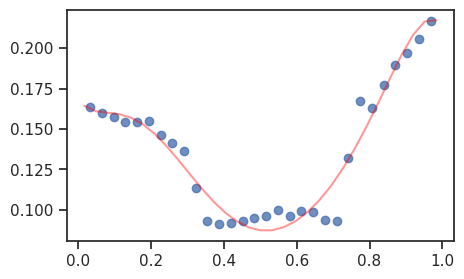

In [73]:
nbins =30
y =  aggregate_params_by_pseudotime(meahr_monocle.obs["vnorm_v1"].values.reshape(1,-1), param_names='g_v1',
                                   timepoints=meahr_monocle.uns['pop']['t'][[0]],
                                    pseudotime_key='pseudotime_scaled', 
                                    adata=meahr_monocle, nbins=nbins+1, return_y=True)
y = y[0]

x_knots = torch.linspace(0,1,nbins)
y_knots = torch.from_numpy(y)

g_cs = models.CubicSpline(x=x_knots, y=y_knots)

g_smooth = g_cs(torch.linspace(0,1,299),None).detach().numpy()
g_smooth = (g_smooth[:-1] + g_smooth[1:])/2
        

Text(0, 0.5, 'pseudodynamics \nvalues')

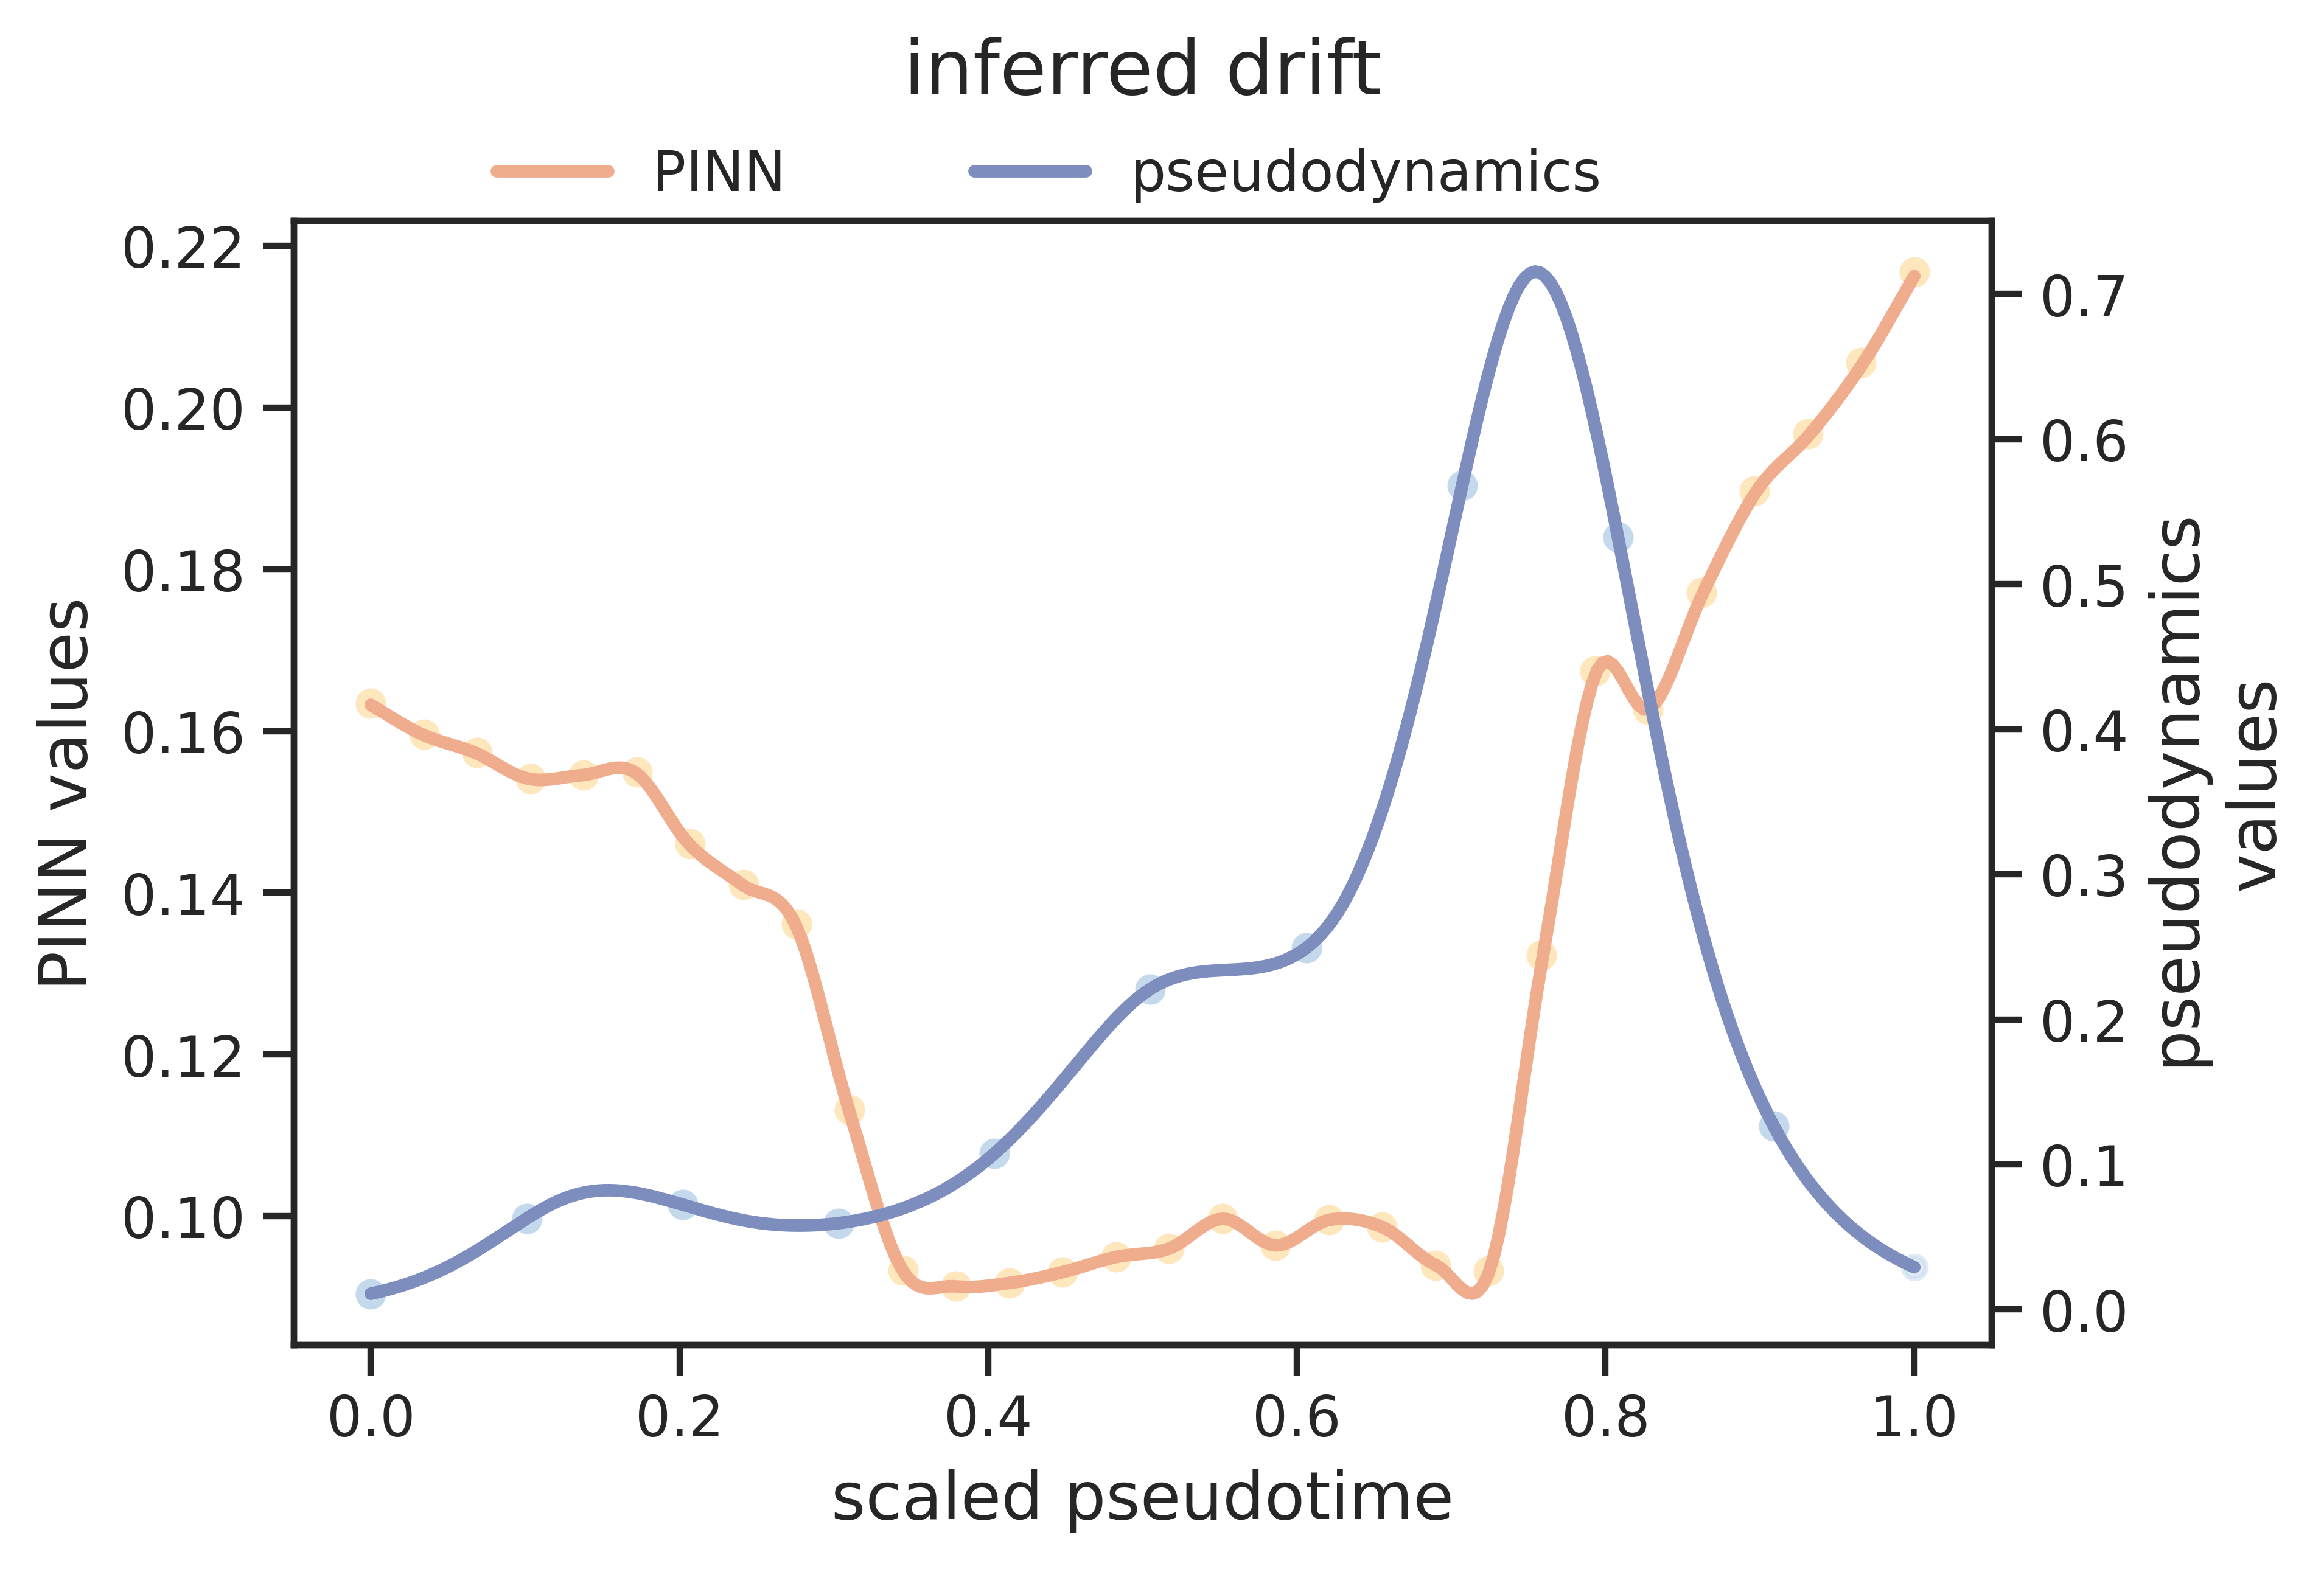

In [102]:
sns.set_theme(style="ticks", font_scale=1)
fig = plt.figure(figsize=(6,4), dpi=600)
ax1 = fig.gca()
ax2 = ax1.twinx()  

ax1.scatter(np.linspace(0,1,nbins), y, color='#FFE7BD', s=25)
ax2.scatter(np.linspace(0,1,298)[np.arange(0,298,30)], pdyn_v[np.arange(0,298,30)],  s=25, color='#C5D9ED')
ax2.scatter(np.linspace(0,1,298)[-1], pdyn_v.values[-1], alpha=0.5, s=20, color='#C5D9ED')

ax2.plot(np.linspace(0,1,298), pdyn_v, label='pseudodynamics', color='#7C8DBE', linewidth=2.5)
ax1.plot(np.linspace(0,1,298), g_smooth, label='PINN ',color="#F0AD8E", linewidth=2.5)

ax1.legend(bbox_to_anchor=[0.13,1.1, 0.2,0.01], frameon=False)
ax2.legend(bbox_to_anchor=[0.6,1.1, 0.2,0.01], frameon=False)

ax1.set_title('inferred drift', pad=25, fontsize=15)
ax1.set_xlabel('scaled pseudotime', fontsize=13)
ax1.set_ylabel('PINN values ', fontsize=13)
ax2.set_ylabel('pseudodynamics \nvalues', fontsize=13)


In [75]:
# velocity

In [ ]:
import scvelo as scv

In [113]:
DM_ad = PINN.tl.make_coord_adata(meahr_monocle,
            cellstate_key='DM_EigenVectors_multiscaled', 
            n_dimension=7, v=params_inv['v_v4'])
DM_ad

AnnData object with n_obs × n_vars = 10104 × 7
    obs: 'barcodes', 'pseudodynamics_branch_class', 'palantir_pseudotime', 'branching_region', 'branch_class', 'time', 'batch', 'pseudotime', 'cell', 'batch_to_match', 'pseudotime_scaled', 'timepoint_tx_days', 'leiden', 'pseudotime_bin', 'g_v3_inv', 'celltype', 'S_score', 'G2M_score', 'phase', 'vnorm_v0', 'vnorm_v1', 'vnorm_v2', 'vnorm_v3', 'vnorm_v4'
    uns: 'DM_EigenValues', 'Time_x_colors', 'Time_y_colors', 'celltype_colors', 'diffmap_evals', 'dpt_changepoints', 'dpt_grouptips', 'iroot', 'leiden', 'leiden_colors', 'leiden_sizes', 'log1p', 'neighbors', 'paga', 'palantir_waypoints', 'pca', 'pop', 'pseudodynamics_branch_class_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'cellstate', 'Day12.5 v', 'Day13.5 v', 'Day14.5 v', 'Day15.5 v', 'Day16.5 v', 'Day17.5 v', 'Day18.5 v', 'Day19.5 v'
    obsp: 'connectivities', 'distances'

In [114]:
vkeys = [k for k in list(DM_ad.layers.keys()) if k.endswith("v")]
sc.pp.neighbors(DM_ad, n_neighbors=15)

computing velocity graph (using 20/256 cores)


  0%|          | 0/10104 [00:00<?, ?cells/s]

    finished (0:00:03) --> added 
    'Day12.5 v_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:01) --> added
    'Day12.5 v_umap', embedded velocity vectors (adata.obsm)
saving figure to file results/meahr/Day12.5 v.png


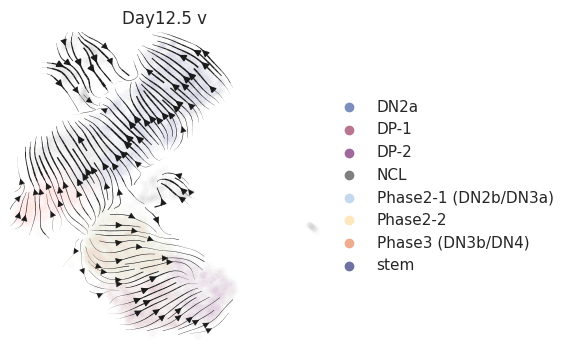

In [115]:
vkey = vkeys[0]

plot_save = "results/meahr"
scv.tl.velocity_graph(DM_ad, vkey=vkey, xkey='cellstate', n_jobs=20)

# vis
fig_velocity = plt.figure(dpi=100, figsize=(4,4))
ax = fig_velocity.gca()
scv.pl.velocity_embedding_stream(DM_ad, color='celltype', vkey=vkey, 
                                    basis='umap', ax=ax, 
                                    legend_loc='right', alpha=0.01,
                                    title=vkey, 
                                    save=f"{plot_save}/{vkey}.png")


# velocity

In [13]:
from torchdiffeq import odeint
import umap

In [14]:
X = meahr_monocle.obsm['DM_EigenVectors_multiscaled']

In [15]:
import umap
init_pos = meahr_monocle.obsm['X_umap']
knn = 50
metric = "euclidean"

umap_transform = umap.UMAP(n_neighbors=knn,init=init_pos, 
                           metric=metric,
                           spread=0.7, min_dist=0.4)
                           #, precomputed_knn=precomputed_knn)

X_umap = umap_transform.fit_transform(X)
plt.figure(figsize=(3,3))
plt.scatter(X_umap[:,0], X_umap[:,1])
plt.title(f"{knn}_{metric}")

In [16]:
precomputed_knn = (meahr_monocle.obsp['connectivities'].A, meahr_monocle.obsp['distances'].A)

Text(0.5, 1.0, '50_euclidean')

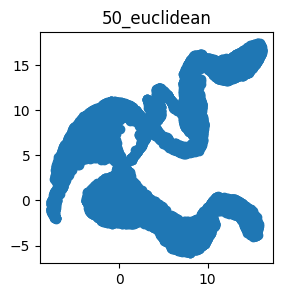

In [71]:
knn = 50
metric = "euclidean"

umap_transform = umap.UMAP(n_neighbors=knn,init=init_pos, 
                           metric=metric,
                           spread=0.7, min_dist=0.4)
                           #, precomputed_knn=precomputed_knn)

X_umap = umap_transform.fit_transform(X)
plt.figure(figsize=(3,3))
plt.scatter(X_umap[:,0], X_umap[:,1])
plt.title(f"{knn}_{metric}")

In [78]:
meahr_monocle.obsm['X_umap_DM'] = X_umap

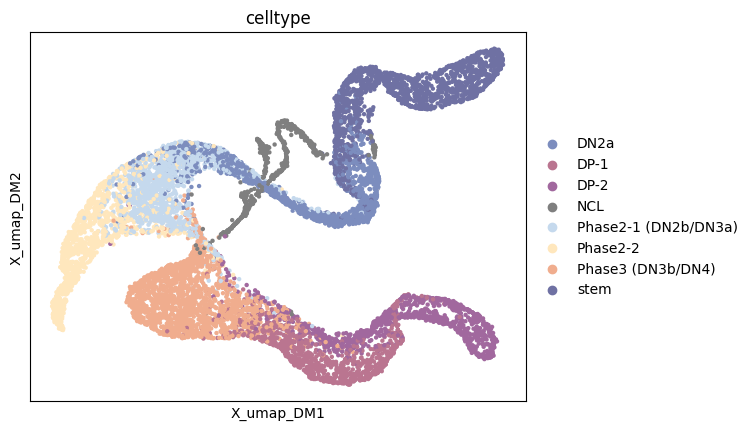

In [80]:
sc.pl.embedding(meahr_monocle, 'X_umap_DM', color='celltype',s=40)

In [77]:
meahr_monocle.obs.celltype.unique()

['DP-1', 'Phase2-2', 'Phase3 (DN3b/DN4)', 'DP-2', 'stem', 'Phase2-1 (DN2b/DN3a)', 'NCL', 'DN2a']
Categories (8, object): ['DN2a', 'DP-1', 'DP-2', 'NCL', 'Phase2-1 (DN2b/DN3a)', 'Phase2-2', 'Phase3 (DN3b/DN4)', 'stem']

In [ ]:
Phase2-1 (DN2b/DN3a)

In [85]:
print(meahr_monocle.obs['pseudotime_bin'].unique())

[0.62, 0.74, 0.58, 0.54, 0.70, ..., 0.30, 0.26, 0.18, 0.02, 0.10]
Length: 25
Categories (25, float64): [0.02 < 0.06 < 0.10 < 0.14 ... 0.86 < 0.90 < 0.94 < 0.98]


In [87]:
selected_celltype = 'Phase2-1 (DN2b/DN3a)'
meahr_monocle.obs.query("`celltype` == @selected_celltype & `pseudotime_bin` == 0.70")

,barcodes,pseudodynamics_branch_class,palantir_pseudotime,branching_region,branch_class,time,batch,pseudotime,cell,batch_to_match,...,g_v3_inv,celltype,S_score,G2M_score,phase,vnorm_v0,vnorm_v1,vnorm_v2,vnorm_v3,vnorm_v4
obs_names,,,,,,,,,,,,,,,,,,,,,
TTTGCGTCGCCG.E17_5_WholeThy_rep2,TTTGCGTCGCCG,TC,0.675153,nonbranching,TC,17.5,E17_5_WholeThy_rep2,19.961206,TTTGCGTCGCCG.E17_5_WholeThy_rep2,E17_5_WholeThy_rep2,...,1.241594,Phase2-1 (DN2b/DN3a),0.189097,0.369940,G2M,0.018806,0.123178,0.018320,0.252536,0.093141
GCTAAATCGCTG.E17_5_WholeThy_rep2,GCTAAATCGCTG,TC,0.504687,nonbranching,TC,17.5,E17_5_WholeThy_rep2,20.124886,GCTAAATCGCTG.E17_5_WholeThy_rep2,E17_5_WholeThy_rep2,...,1.159526,Phase2-1 (DN2b/DN3a),0.453044,0.724705,G2M,0.010325,0.070541,0.020647,0.182186,0.085913
CTATCGCGCAGC.E17_5_WholeThy_rep2,CTATCGCGCAGC,TC,0.539700,nonbranching,TC,17.5,E17_5_WholeThy_rep2,20.443602,CTATCGCGCAGC.E17_5_WholeThy_rep2,E17_5_WholeThy_rep2,...,1.245571,Phase2-1 (DN2b/DN3a),0.146094,0.563106,G2M,0.011473,0.060569,0.019911,0.197417,0.087739
TCACGGCAACCG.E17_5_WholeThy_rep2,TCACGGCAACCG,TC,0.486764,nonbranching,TC,17.5,E17_5_WholeThy_rep2,20.065649,TCACGGCAACCG.E17_5_WholeThy_rep2,E17_5_WholeThy_rep2,...,1.022478,Phase2-1 (DN2b/DN3a),0.324065,0.650927,G2M,0.008770,0.080370,0.023493,0.156200,0.083477
TCCAAGAGCCTC.E17_5_WholeThy_rep2,TCCAAGAGCCTC,TC,0.525962,nonbranching,TC,17.5,E17_5_WholeThy_rep2,20.432935,TCCAAGAGCCTC.E17_5_WholeThy_rep2,E17_5_WholeThy_rep2,...,1.181165,Phase2-1 (DN2b/DN3a),0.228429,0.605419,G2M,0.011395,0.065692,0.018410,0.199136,0.088997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACTTGCTATCCG.E14_5_WholeThy_rep1,ACTTGCTATCCG,TC,0.426283,nonbranching,TC,14.5,E14_5_WholeThy_rep2,20.323989,ACTTGCTATCCG.E14_5_WholeThy_rep2,E14_5_WholeThy_rep2,...,0.573935,Phase2-1 (DN2b/DN3a),-0.125464,0.700839,G2M,0.006197,0.105300,0.029012,0.104853,0.076448
TTCTCTGATCTT.E14_5_WholeThy_rep1,TTCTCTGATCTT,TC,0.527621,nonbranching,TC,14.5,E14_5_WholeThy_rep2,20.601886,TTCTCTGATCTT.E14_5_WholeThy_rep2,E14_5_WholeThy_rep2,...,1.221792,Phase2-1 (DN2b/DN3a),-0.205032,1.215685,G2M,0.010429,0.066465,0.022042,0.181407,0.085719
CCGGTCATAGGG.E14_5_WholeThy_rep1,CCGGTCATAGGG,TC,0.476541,nonbranching,TC,14.5,E14_5_WholeThy_rep2,20.215934,CCGGTCATAGGG.E14_5_WholeThy_rep2,E14_5_WholeThy_rep2,...,0.891971,Phase2-1 (DN2b/DN3a),0.035230,0.779931,G2M,0.008101,0.084903,0.024021,0.146565,0.082469


In [73]:
model = models.pde_params.load_from_checkpoint(inv_ckpt['ckpt_v1'])

In [74]:
scaler = model.time_scale_factor
def drift(t, states):
    device = states.device
    t_in = torch.full((states.shape[0],), t.item()*scaler).float()
    v = model.v(states, t)
    return v

In [ ]:
DMs = odeint(drift, )

In [ ]:
DM = 

# umap params

<Axes: title={'center': 'inferred drift \n (vector sum)'}, xlabel='UMAP1', ylabel='UMAP2'>

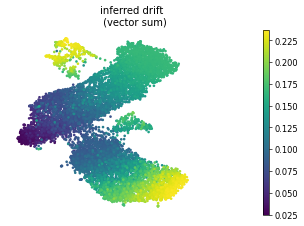

In [48]:
# fig, axs = plt.subplots(1,1,figsize=(4,4),dpi=600, frameon=False)
fig, axs = plt.subplots(1,1,figsize=(6,4),dpi=60)

ax = axs

sc.pl.umap(meahr_monocle,
           frameon=False, size=0, ax=ax, show=False)
sc.pl.umap(meahr_monocle_plot, color='vnorm_v1',
           frameon=False, size=40, ax=ax, show=False, cmap='viridis',
           title='inferred drift \n (vector sum)')

# fig.savefig("results/meahr/drift_umap.pdf")